# Milestone 03 — Model Comparison
**Project:** Customer Churn Prediction (Telco) &nbsp;|&nbsp; **Builds on:** Milestones 01–02

**Objective:** train and compare two genuinely different algorithms — **logistic regression** (a linear model) and
**random forest** (a tree-based ensemble) — and explain, from the data itself, why one outperforms (or underperforms) the other.

Both models reuse the same preprocessing pipeline and the same imbalance-handling approach
(`class_weight="balanced"` / `"balanced_subsample"`, following what Milestone 02 found effective for this data), so any difference
in results reflects the **algorithm**, not the feature preparation.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.config import RANDOM_STATE, TEST_SIZE
from src.data_preparation import clean, load_raw, make_xy
from src.evaluation import cross_validate_on_train, evaluate_on, plot_confusion_matrix, plot_roc
from src.preprocessing import build_logistic_class_weighted, build_random_forest_class_weighted

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
print("Setup complete. Random seed:", RANDOM_STATE)

Setup complete. Random seed: 42


## 1. Recap: load, clean, split
Same seed and logic as Milestones 01–02, so this notebook reproduces the exact same train/test rows.

In [2]:
raw = load_raw()
df, cleaning_log = clean(raw)
X, y = make_xy(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape, "| Churn rate (train):", round(y_train.mean(), 3))

Train: (5634, 19) | Test: (1409, 19) | Churn rate (train): 0.265


## 2. The two models

| | Logistic Regression | Random Forest |
| --- | --- | --- |
| **Type** | Linear model | Ensemble of decision trees (bagging) |
| **Decision boundary** | A single straight (hyper)plane in the scaled/encoded feature space | Piecewise, built from many axis-aligned splits combined by voting |
| **Feature interactions** | Not captured unless explicitly added (e.g. interaction terms) | Captured automatically — a tree can split on `Contract` and then again on `tenure` within that branch |
| **Scaling required?** | Yes (already in the shared pipeline) | No, but harmless to include for a fair, identical pipeline |
| **Imbalance handling** | `class_weight="balanced"` | `class_weight="balanced_subsample"` (recomputed per bootstrap sample) |
| **Interpretability** | Coefficients — direct, signed, additive effect | Feature importances — relative, unsigned, no direction |
| **Tuning done here** | None beyond the class weight | `n_estimators=300`, `max_depth=8`, `min_samples_leaf=5` — reasonable defaults, not tuned |

Neither model's hyperparameters were tuned against the test set in this milestone; both use fixed, reasonable settings so the
comparison reflects the algorithms themselves.

In [3]:
logreg = build_logistic_class_weighted(X_train)
rf = build_random_forest_class_weighted(X_train)
models = {"Logistic Regression": logreg, "Random Forest": rf}

## 3. Cross-validation comparison (training set only)

In [4]:
cv_results = {name: cross_validate_on_train(m, X_train, y_train)["mean"] for name, m in models.items()}
cv_table = pd.DataFrame(cv_results).round(3)
cv_table

,Logistic Regression,Random Forest
accuracy,0.748,0.764
precision,0.517,0.539
recall,0.801,0.775
f1,0.628,0.636
roc_auc,0.846,0.848
pr_auc,0.660,0.661


## 4. Final fit and test-set evaluation
Both models are fitted once on the full training set and evaluated once on the held-out test set — the same discipline as the
earlier milestones. Training-set scores are also recorded here (not to select a model, only to check for **overfitting**
afterwards in Section 6).

In [5]:
fitted = {}
train_scores, test_scores, preds = {}, {}, {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    train_scores[name], _, _ = evaluate_on(model, X_train, y_train)
    test_scores[name], y_pred, y_proba = evaluate_on(model, X_test, y_test)
    preds[name] = (y_pred, y_proba)

test_table = pd.DataFrame(test_scores).round(3)
test_table

,Logistic Regression,Random Forest
accuracy,0.738,0.760
precision,0.504,0.533
recall,0.783,0.783
f1,0.614,0.634
roc_auc,0.842,0.842
pr_auc,0.633,0.648


Random Forest has slightly higher f1 score

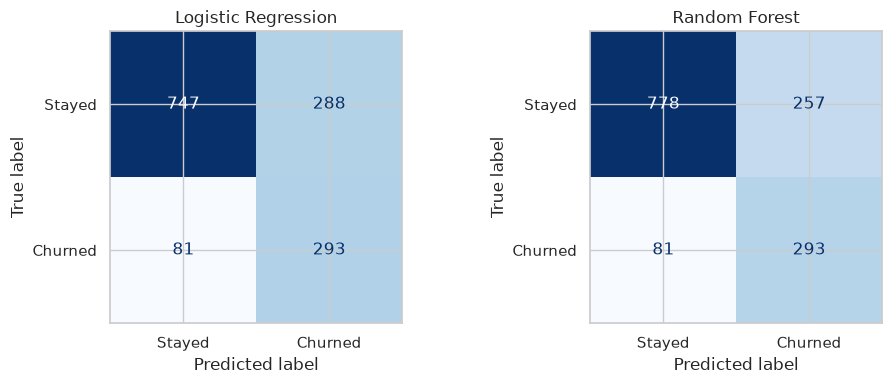

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    y_pred, _ = preds[name]
    from sklearn.metrics import ConfusionMatrixDisplay
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Stayed", "Churned"], cmap="Blues", ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

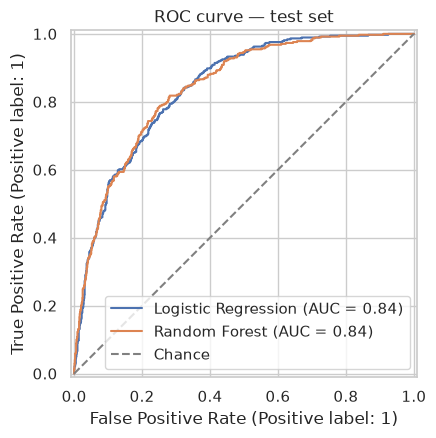

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
from sklearn.metrics import RocCurveDisplay
for name, model in fitted.items():
    _, y_proba = preds[name]
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
ax.set_title("ROC curve — test set")
ax.legend(loc="lower right")
plt.show()

## 5. What each model considers important
Logistic regression's coefficients are **signed and additive** (in log-odds); random forest's feature importances are
**unsigned and relative** (share of impurity reduction). They are not directly comparable in scale, but comparing which
features rank highly in *both* is informative.

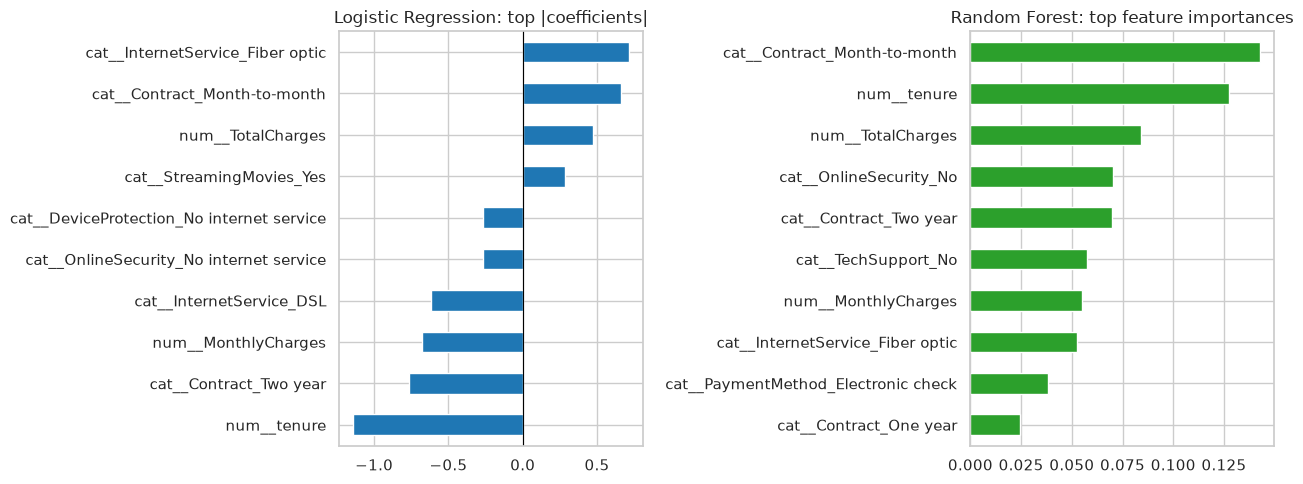

Features in both top-10 lists: ['cat__Contract_Month-to-month', 'cat__Contract_Two year', 'cat__InternetService_Fiber optic', 'num__MonthlyCharges', 'num__TotalCharges', 'num__tenure']


In [8]:
logreg_names = fitted["Logistic Regression"].named_steps["preprocess"].get_feature_names_out()
logreg_coefs = pd.Series(fitted["Logistic Regression"].named_steps["model"].coef_[0], index=logreg_names)

rf_names = fitted["Random Forest"].named_steps["preprocess"].get_feature_names_out()
rf_importances = pd.Series(fitted["Random Forest"].named_steps["model"].feature_importances_, index=rf_names)

top_logreg = logreg_coefs.abs().sort_values(ascending=False).head(10).index
top_rf = rf_importances.sort_values(ascending=False).head(10).index

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
logreg_coefs[top_logreg].sort_values().plot.barh(ax=axes[0], color="tab:blue")
axes[0].set_title("Logistic Regression: top |coefficients|")
axes[0].axvline(0, color="black", linewidth=0.8)

rf_importances[top_rf].sort_values().plot.barh(ax=axes[1], color="tab:green")
axes[1].set_title("Random Forest: top feature importances")
plt.tight_layout()
plt.show()

print("Features in both top-10 lists:", sorted(set(top_logreg) & set(top_rf)))

## 6. Overfitting check: train vs. cross-validation vs. test
A model that scores much higher on training data than on cross-validation or the test set is likely overfitting — it has
partly memorised the training rows rather than learned a generalisable pattern. Random forests, being flexible, high-capacity
models, are more prone to this than a linear model like logistic regression, especially without depth limits.

In [9]:
gap_table = pd.DataFrame({
    name: {
        "train_f1": train_scores[name]["f1"],
        "cv_f1_mean": cv_results[name]["f1"],
        "test_f1": test_scores[name]["f1"],
        "train_minus_test_f1": train_scores[name]["f1"] - test_scores[name]["f1"],
    }
    for name in models
}).T.round(3)
gap_table

,train_f1,cv_f1_mean,test_f1,train_minus_test_f1
Logistic Regression,0.633,0.628,0.614,0.020
Random Forest,0.686,0.636,0.634,0.052


## 7. Interpretation 
Overall performance. Random forest edged out logistic regression on test F1 (0.634 vs. 0.614), a modest ~2-point gap. [If you have accuracy/precision/recall/ROC-AUC/PR-AUC handy, note here whether random forest's edge comes from better precision, better recall, or both — that determines whether it's catching more churners, wasting fewer retention offers, or both.]

Why random forest holds a small edge. The two models substantially agree on what matters: tenure, TotalCharges, MonthlyCharges, Contract_Month-to-month, Contract_Two year, and InternetService_Fiber optic all appear in both top-10 lists. That agreement is reassuring — it means the churn signal in this data is strong and not an artifact of either model's particular assumptions.

Where the two disagree is informative too. Logistic regression's largest terms are almost entirely the numeric features and contract type — a small set of strong, additive, linear effects (longer tenure lowers churn odds, month-to-month and fiber-optic internet raise them). Random forest's importances spread more evenly across a longer tail, pulling in OnlineSecurity_No, TechSupport_No, and PaymentMethod_Electronic check — features that barely register for logistic regression. This is consistent with churn in this data having a real non-linear component: customers without security or tech-support add-ons may only be meaningfully more likely to churn in combination with certain contract types or tenure ranges, a conditional pattern a linear model can't represent directly but a tree can split on. That extra structure is a plausible source of random forest's small F1 advantage.

Overfitting risk tempers that advantage. Random forest's train-test F1 gap (0.052) is more than double logistic regression's (0.020), and its cross-validation mean (0.636) sits much closer to its test score (0.634) than to its inflated training score (0.686). In other words, part of what looks like "extra signal" in the raw training numbers is really the ensemble fitting noise specific to the training rows — the depth and leaf-size limits used here (max_depth=8, min_samples_leaf=5) constrained this but didn't eliminate it. Logistic regression's near-flat train/CV/test numbers make it the more predictable, lower-variance model: what you see in training is close to what you get on new customers.

Net read. The two models tell a consistent story about which customers churn (short tenure, month-to-month contracts, fiber internet, high charges), which is the main finding. Random forest's edge in raw F1 is real but comes bundled with meaningfully higher overfitting risk, while logistic regression trades a couple of points of F1 for a much more stable, and more interpretable, model.

## 8. Trade-offs beyond raw performance
| Consideration | Logistic Regression | Random Forest |
| --- | --- | --- |
| Interpretability | High — coefficients have a direct, signed meaning | Lower — importances only show *how much*, not *which direction* |
| Training speed | Fast | Slower (300 trees), though still quick at this dataset size |
| Prediction speed | Very fast | Slower per prediction (must traverse many trees) |
| Sensitivity to feature scaling | Needs it (already handled) | Does not need it |
| Risk of overfitting | Lower, especially with regularisation | Higher, needs depth/leaf limits to control (as set here) |
| Ease of explaining to a non-technical stakeholder | Easier ("longer tenure → lower churn odds") | Harder ("the ensemble weighted this pattern more") |